<a href="https://colab.research.google.com/github/CauaMaia/processamento_de_imagens/blob/main/atividade_pdi_equipe_caua_matheus_henrique.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho de Processamento Digital de Imagens

**Equipe:** Cauã Maia, Henrique Gonçalves e Matheus Carvalho

**Objetivo:** diagnosticar o problema de visualização/preparação de 5 imagens distintas, escolher e aplicar a transformação de intensidade mais adequada para cada uma (negativo digital, limiarização, expansão de contraste, equalização de histograma e correção Gamma), comparando imagem e histograma antes e depois do processamento. Ao final, uma das imagens é usada para uma análise de quantização em 16, 8 e 4 níveis de cinza.


## 1. Importação das bibliotecas

In [29]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import cv2


In [30]:
from google.colab import files
uploaded = files.upload()

Saving imagem_01.png to imagem_01 (2).png
Saving imagem_02.png to imagem_02 (2).png
Saving imagem_03.png to imagem_03 (2).png
Saving imagem_04.png to imagem_04 (2).png
Saving imagem_05.png to imagem_05 (2).png


## 2. Funções auxiliares (leitura, histograma e transformações)

In [31]:
def carregar_cinza(caminho):
    """Carrega uma imagem e converte para escala de cinza (uint8)."""
    img = Image.open(caminho).convert("L")
    return np.array(img)


def comparar(original, resultado, titulo_caso, titulo_original="Original", titulo_resultado="Resultado"):
    """Mostra, em um único grid 2x2:
       [imagem original | histograma original]
       [imagem resultado | histograma resultado]
    """
    fig, axs = plt.subplots(2, 2, figsize=(11, 9))
    fig.suptitle(titulo_caso, fontsize=14, fontweight="bold")

    axs[0, 0].imshow(original, cmap="gray", vmin=0, vmax=255)
    axs[0, 0].set_title(titulo_original)
    axs[0, 0].axis("off")

    axs[0, 1].hist(original.ravel(), bins=256, range=(0, 255), color="gray")
    axs[0, 1].set_title(f"Histograma - {titulo_original}")
    axs[0, 1].set_xlabel("Nível de cinza")
    axs[0, 1].set_ylabel("Frequência")

    axs[1, 0].imshow(resultado, cmap="gray", vmin=0, vmax=255)
    axs[1, 0].set_title(titulo_resultado)
    axs[1, 0].axis("off")

    axs[1, 1].hist(resultado.ravel(), bins=256, range=(0, 255), color="gray")
    axs[1, 1].set_title(f"Histograma - {titulo_resultado}")
    axs[1, 1].set_xlabel("Nível de cinza")
    axs[1, 1].set_ylabel("Frequência")

    plt.tight_layout()
    plt.show()


In [32]:
# --- Transformações de intensidade ---

def negativo_digital(img):
    """s = 255 - r"""
    return (255 - img).astype(np.uint8)


def limiarizacao(img, T):
    """Binarização simples: 255 se img > T, senão 0."""
    return np.where(img > T, 255, 0).astype(np.uint8)


def expansao_contraste(img):
    """Alonga linearmente [min, max] da imagem para [0, 255]."""
    minv, maxv = img.min(), img.max()
    if maxv == minv:
        return img.copy()
    saida = (img.astype(np.float32) - minv) * (255.0 / (maxv - minv))
    return np.clip(saida, 0, 255).astype(np.uint8)


def equalizacao_histograma(img):
    """Equalização clássica via CDF do histograma."""
    hist, _ = np.histogram(img.flatten(), bins=256, range=(0, 256))
    cdf = hist.cumsum()
    cdf_normalizada = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())
    cdf_normalizada = cdf_normalizada.astype(np.uint8)
    return cdf_normalizada[img]


def correcao_gamma(img, gamma):
    """s = 255 * (r/255) ** gamma"""
    normalizado = img.astype(np.float32) / 255.0
    corrigido = np.power(normalizado, gamma)
    return np.uint8(np.clip(corrigido * 255, 0, 255))


def quantizar(img, niveis):
    """Reduz a imagem para um número menor de níveis de cinza (0-255)."""
    fator = 256 // niveis
    img_quant = (img // fator) * fator
    return img_quant.astype(np.uint8)


## 3. Caso 1 — `imagem_01.png` (sementes de girassol)

Dimensões: (941, 1672) | min: 0 | max: 221 | média: 56.9


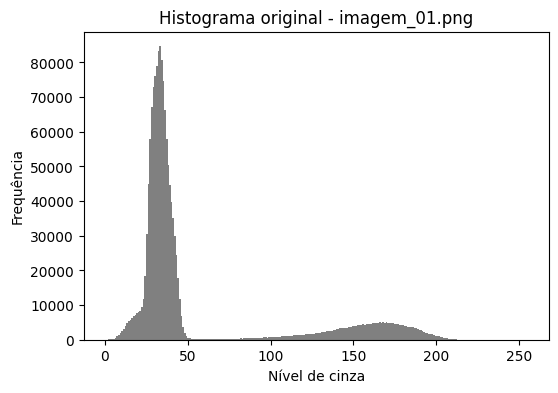

In [33]:
img1 = carregar_cinza(CAMINHOS[1])
print("Dimensões:", img1.shape, "| min:", img1.min(), "| max:", img1.max(), "| média:", round(img1.mean(), 1))

plt.figure(figsize=(6, 4))
plt.hist(img1.ravel(), bins=256, range=(0, 255), color="gray")
plt.title("Histograma original - imagem_01.png")
plt.xlabel("Nível de cinza")
plt.ylabel("Frequência")
plt.show()


**Diagnóstico:** o histograma é claramente **bimodal**: um pico forte próximo do preto (fundo escuro) e outro pico em tons de cinza claro (as sementes). Não há problema de exposição — a imagem já usa quase toda a faixa dinâmica — mas sim uma tarefa de **segmentação**: separar os objetos de interesse do fundo.

**Técnica escolhida:** *Limiarização (thresholding)* simples, com limiar `T` escolhido no vale entre os dois picos do histograma (`T ≈ 90`).

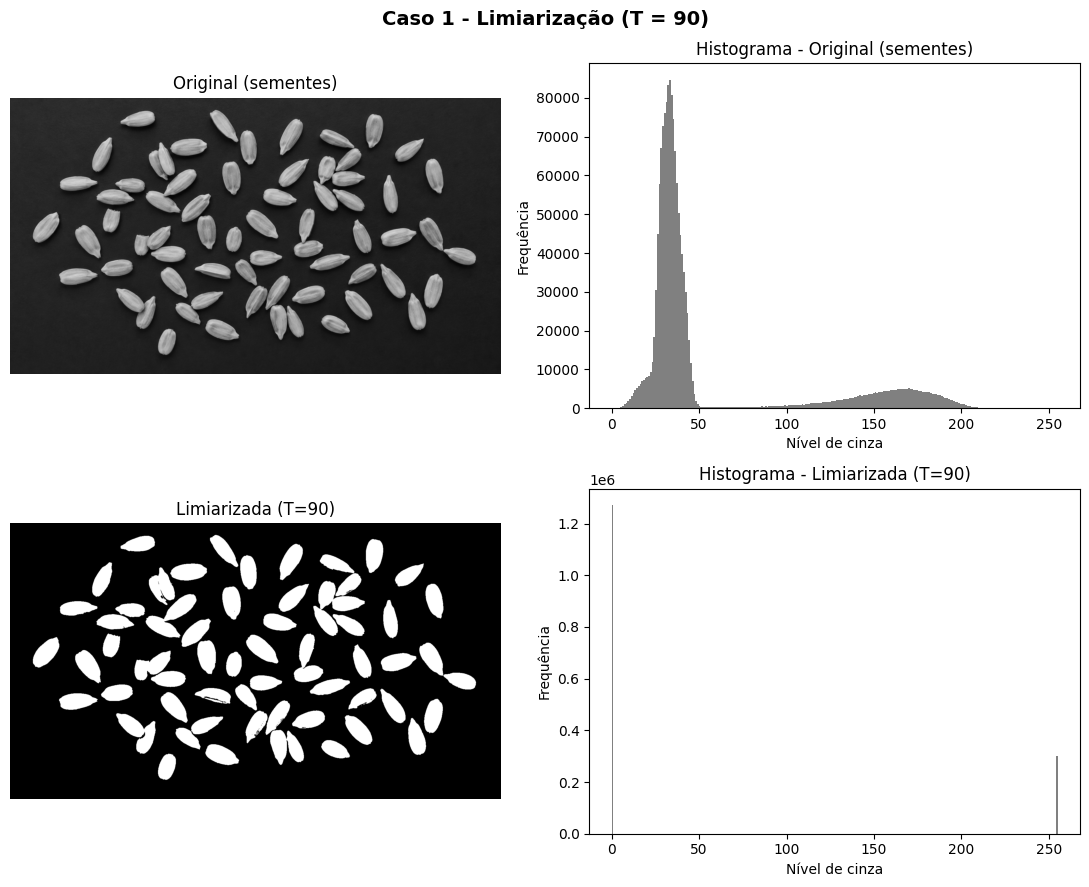

In [34]:
T = 90
resultado1 = limiarizacao(img1, T)
comparar(img1, resultado1, "Caso 1 - Limiarização (T = 90)",
         titulo_original="Original (sementes)", titulo_resultado=f"Limiarizada (T={T})")


**Justificativa:** como o histograma é bimodal, um único limiar é suficiente para separar sementes (objeto) e fundo sem perder informação relevante, gerando uma máscara binária útil, por exemplo, para contar ou medir as sementes automaticamente.

## 4. Caso 2 — `imagem_02.png` (corredor escuro)

Dimensões: (941, 1672) | min: 0 | max: 243 | média: 12.3


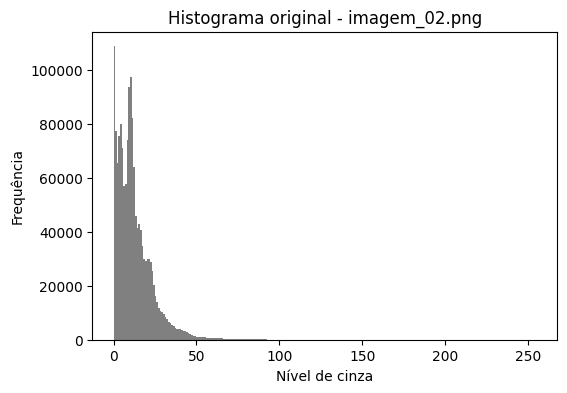

In [35]:
img2 = carregar_cinza(CAMINHOS[2])
print("Dimensões:", img2.shape, "| min:", img2.min(), "| max:", img2.max(), "| média:", round(img2.mean(), 1))

plt.figure(figsize=(6, 4))
plt.hist(img2.ravel(), bins=256, range=(0, 255), color="gray")
plt.title("Histograma original - imagem_02.png")
plt.xlabel("Nível de cinza")
plt.ylabel("Frequência")
plt.show()


**Diagnóstico:** a imagem está fortemente **subexposta** (média ≈ 12): quase todos os pixels estão concentrados na região escura do histograma, tornando os detalhes do corredor quase invisíveis, exceto pela lâmpada ao fundo.

**Técnica escolhida:** *Correção Gamma* com `gamma = 0.35` (γ < 1), que expande as regiões escuras e comprime as claras.

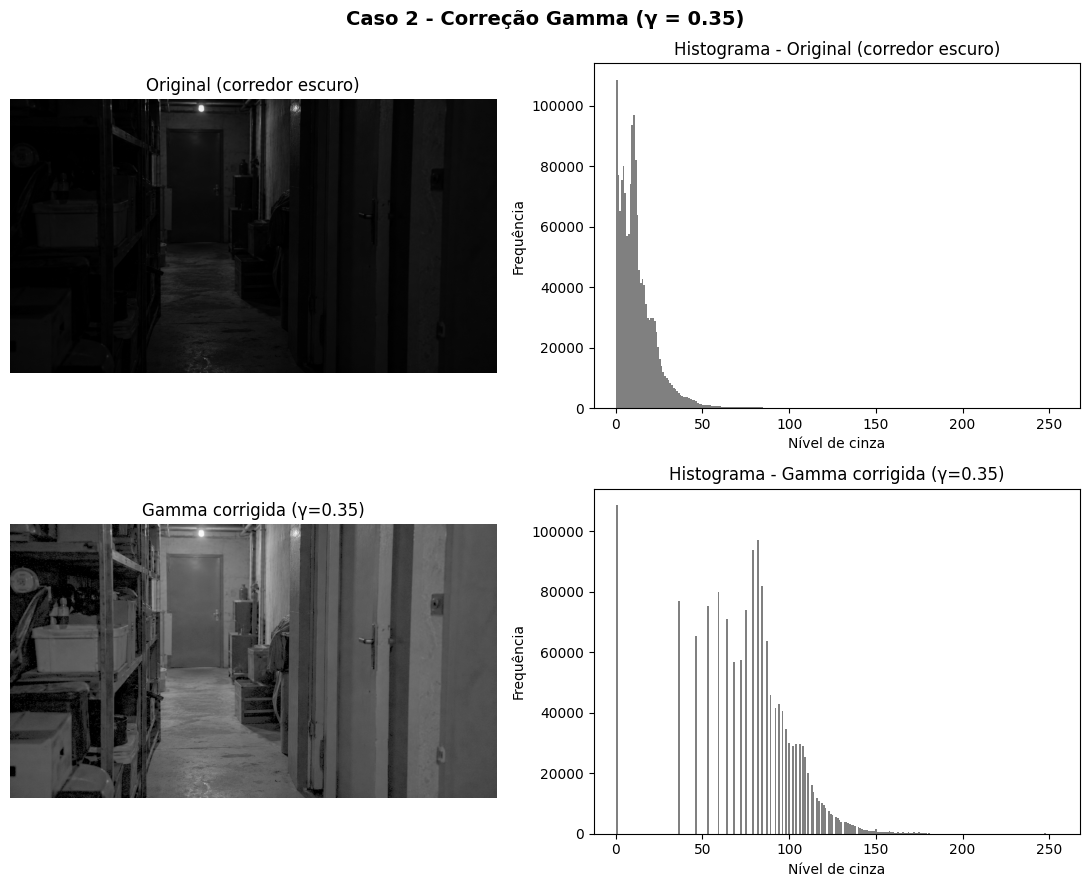

In [36]:
gamma_val = 0.35
resultado2 = correcao_gamma(img2, gamma_val)
comparar(img2, resultado2, "Caso 2 - Correção Gamma (γ = 0.35)",
         titulo_original="Original (corredor escuro)", titulo_resultado=f"Gamma corrigida (γ={gamma_val})")


**Justificativa:** a correção Gamma é mais adequada que uma equalização global aqui, pois preserva a relação tonal suave da cena e evita amplificar excessivamente o ruído presente nas sombras mais profundas, realçando os detalhes das prateleiras e da porta sem estourar a região da lâmpada.

## 5. Caso 3 — `imagem_03.png` (raio-X de turbina)

Dimensões: (941, 1672) | min: 4 | max: 230 | média: 48.6


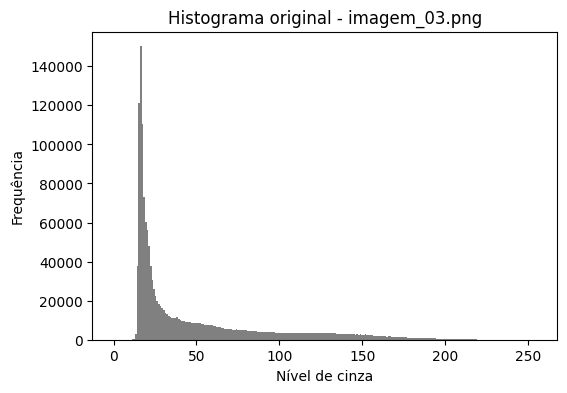

In [37]:
img3 = carregar_cinza(CAMINHOS[3])
print("Dimensões:", img3.shape, "| min:", img3.min(), "| max:", img3.max(), "| média:", round(img3.mean(), 1))

plt.figure(figsize=(6, 4))
plt.hist(img3.ravel(), bins=256, range=(0, 255), color="gray")
plt.title("Histograma original - imagem_03.png")
plt.xlabel("Nível de cinza")
plt.ylabel("Frequência")
plt.show()


**Diagnóstico:** a imagem já possui boa faixa dinâmica (0–230) e bom contraste entre as peças internas da turbina, porém está na **polaridade invertida** em relação à visualização radiográfica tradicional: as estruturas mais densas aparecem claras sobre fundo escuro, diferente do padrão de filme radiográfico (estruturas densas em tons escuros sobre fundo claro).

**Técnica escolhida:** *Negativo digital* (`s = 255 − r`), aplicado a toda a imagem.

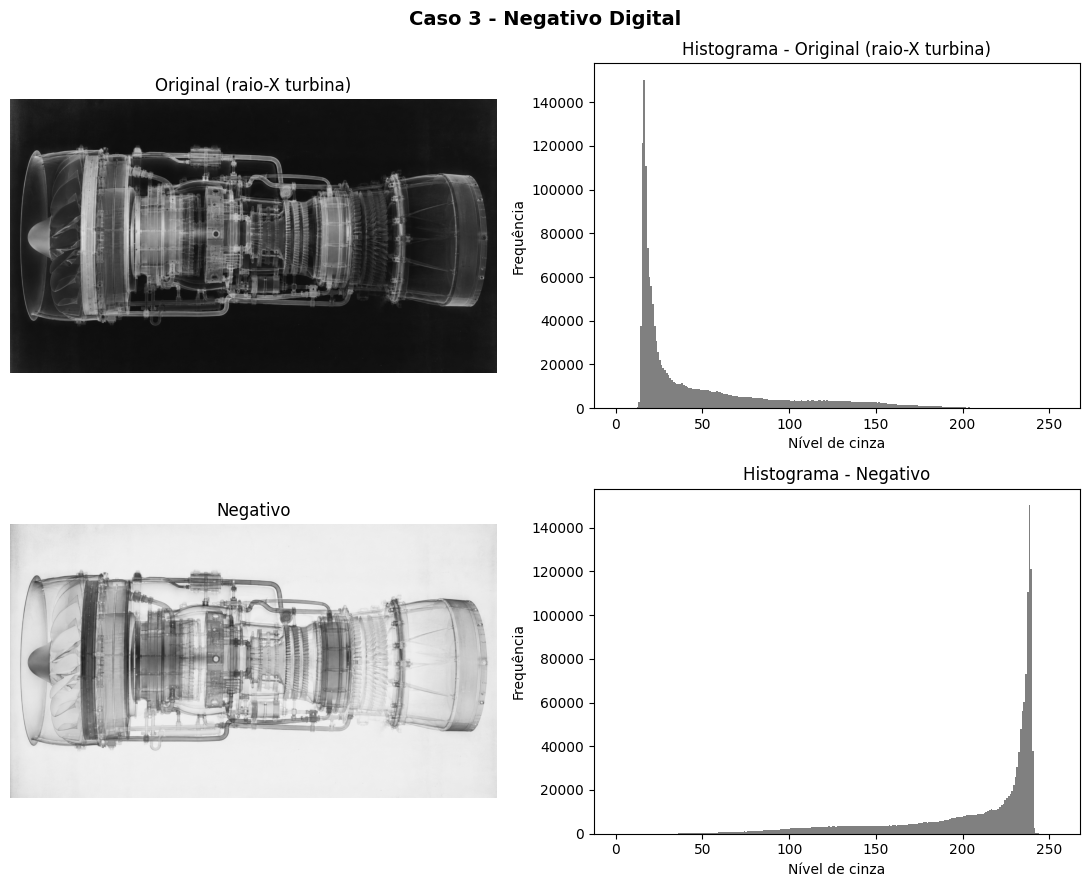

In [38]:
resultado3 = negativo_digital(img3)
comparar(img3, resultado3, "Caso 3 - Negativo Digital",
         titulo_original="Original (raio-X turbina)", titulo_resultado="Negativo")


**Justificativa:** a transformação negativa apenas inverte a polaridade tonal, sem alterar o contraste relativo entre as estruturas internas, permitindo visualizar a peça no padrão tradicional de filme radiográfico, mais familiar para inspeção visual das partes mecânicas.

## 6. Caso 4 — `imagem_04.png` (rua/avenida)

Dimensões: (941, 1672) | min: 57 | max: 218 | média: 98.8


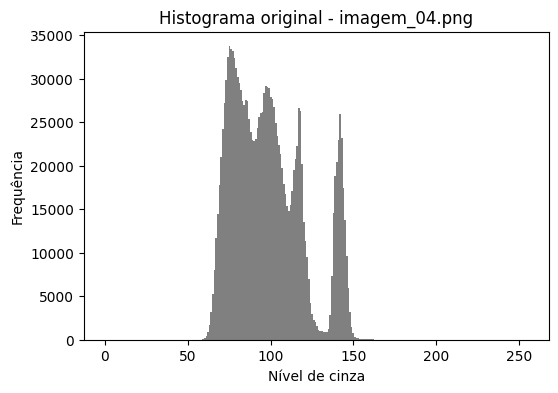

In [39]:
img4 = carregar_cinza(CAMINHOS[4])
print("Dimensões:", img4.shape, "| min:", img4.min(), "| max:", img4.max(), "| média:", round(img4.mean(), 1))

plt.figure(figsize=(6, 4))
plt.hist(img4.ravel(), bins=256, range=(0, 255), color="gray")
plt.title("Histograma original - imagem_04.png")
plt.xlabel("Nível de cinza")
plt.ylabel("Frequência")
plt.show()


**Diagnóstico:** a imagem apresenta **baixo contraste global**, com o histograma concentrado numa faixa de cinzas médios (57–218), efeito típico de neblina/luz difusa, o que faz prédios e veículos ao fundo perderem definição.

**Técnica escolhida:** *Equalização de histograma*, redistribuindo os níveis de cinza para que o histograma resultante fique aproximadamente uniforme.

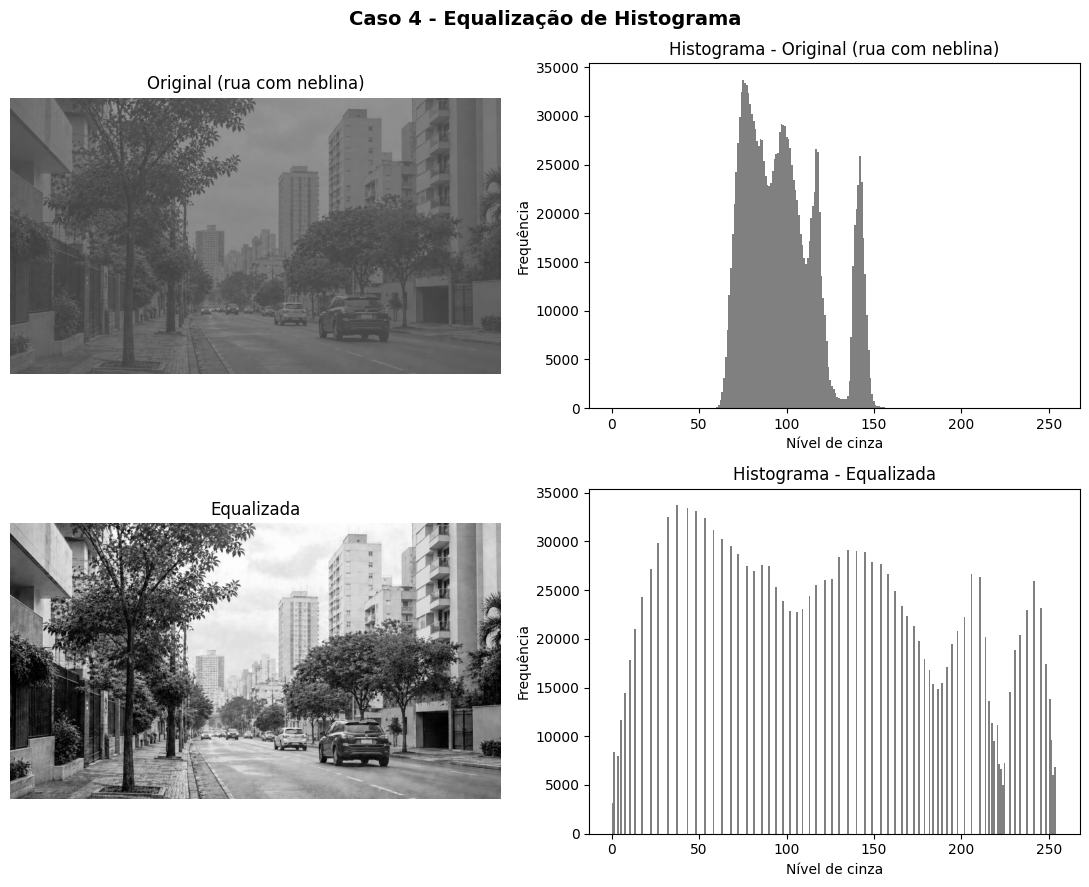

In [40]:
resultado4 = equalizacao_histograma(img4)
comparar(img4, resultado4, "Caso 4 - Equalização de Histograma",
         titulo_original="Original (rua com neblina)", titulo_resultado="Equalizada")


**Justificativa:** diferente de uma expansão linear simples, a equalização de histograma realça mais os detalhes nas regiões de maior densidade de pixels (tons médios), o que é ideal aqui, já que a maior parte da informação da cena está concentrada nessa faixa estreita e a distribuição original não é uniforme.

## 7. Caso 5 — `imagem_05.png` (peça mecânica)

Dimensões: (941, 1672) | min: 75 | max: 141 | média: 103.3


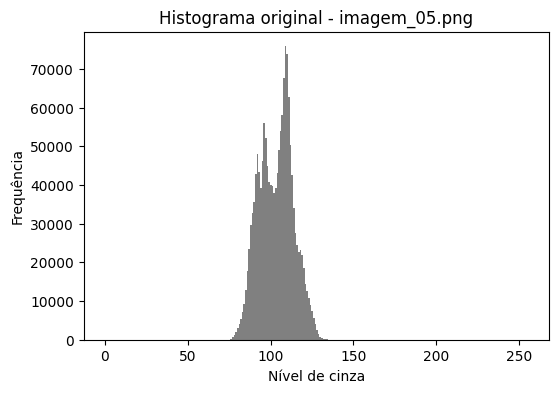

In [41]:
img5 = carregar_cinza(CAMINHOS[5])
print("Dimensões:", img5.shape, "| min:", img5.min(), "| max:", img5.max(), "| média:", round(img5.mean(), 1))

plt.figure(figsize=(6, 4))
plt.hist(img5.ravel(), bins=256, range=(0, 255), color="gray")
plt.title("Histograma original - imagem_05.png")
plt.xlabel("Nível de cinza")
plt.ylabel("Frequência")
plt.show()


**Diagnóstico:** a imagem tem iluminação uniforme, mas ocupa apenas uma **faixa muito estreita e central** do intervalo de cinzas (75–141, amplitude de apenas 66 níveis), resultando em baixíssimo contraste, embora a distribuição dentro dessa faixa já seja relativamente regular (não há necessidade de redistribuição, como na equalização).

**Técnica escolhida:** *Expansão de contraste (linear stretching)*, mapeando o intervalo [min, max] da imagem original para [0, 255].

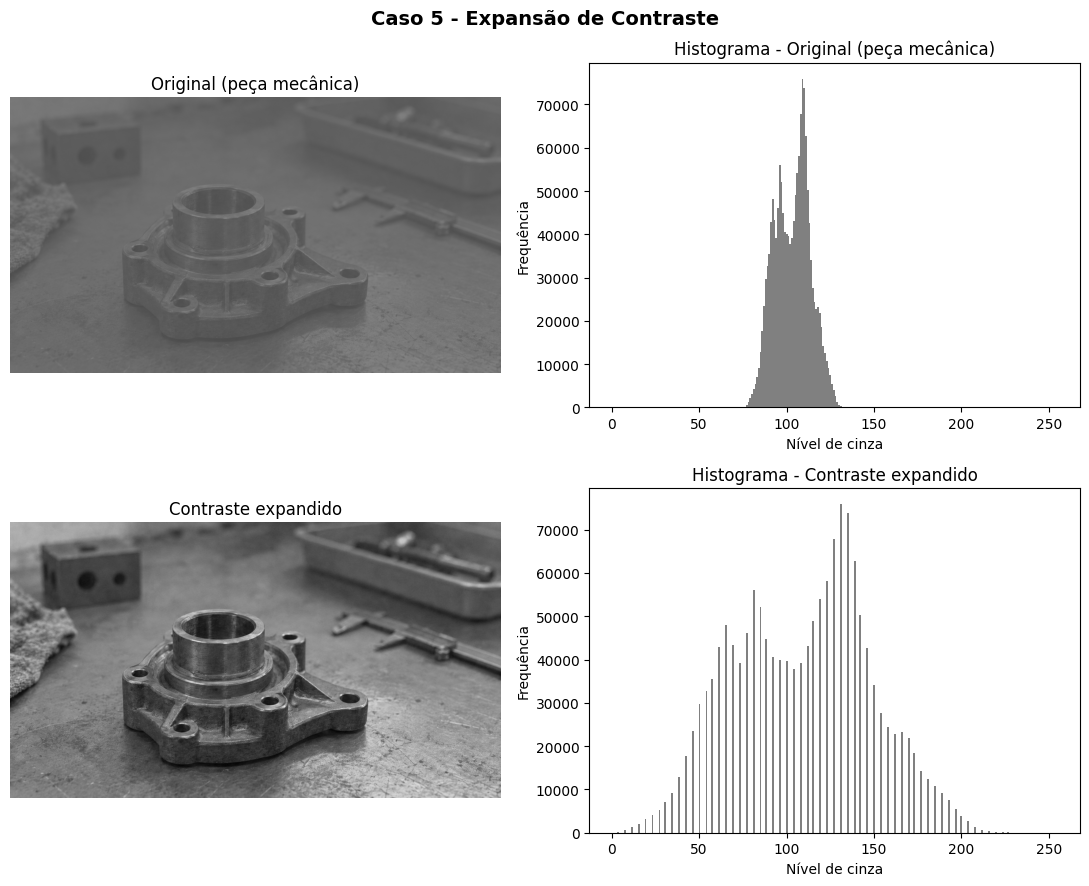

In [42]:
resultado5 = expansao_contraste(img5)
comparar(img5, resultado5, "Caso 5 - Expansão de Contraste",
         titulo_original="Original (peça mecânica)", titulo_resultado="Contraste expandido")


**Justificativa:** como a distribuição de tons já é relativamente regular dentro de uma faixa estreita, um simples alongamento linear é suficiente para ocupar toda a faixa dinâmica disponível (0–255), sem distorcer as proporções relativas entre os níveis de cinza como faria a equalização de histograma.

## 8. Quantização — `imagem_05.png` (peça mecânica)

A imagem da peça mecânica foi escolhida para o estudo de quantização por apresentar **gradientes suaves e contínuos** de tom (reflexos metálicos), o que evidencia bem o efeito de bandas falsas (*false contouring*) causado pela redução do número de níveis de cinza.

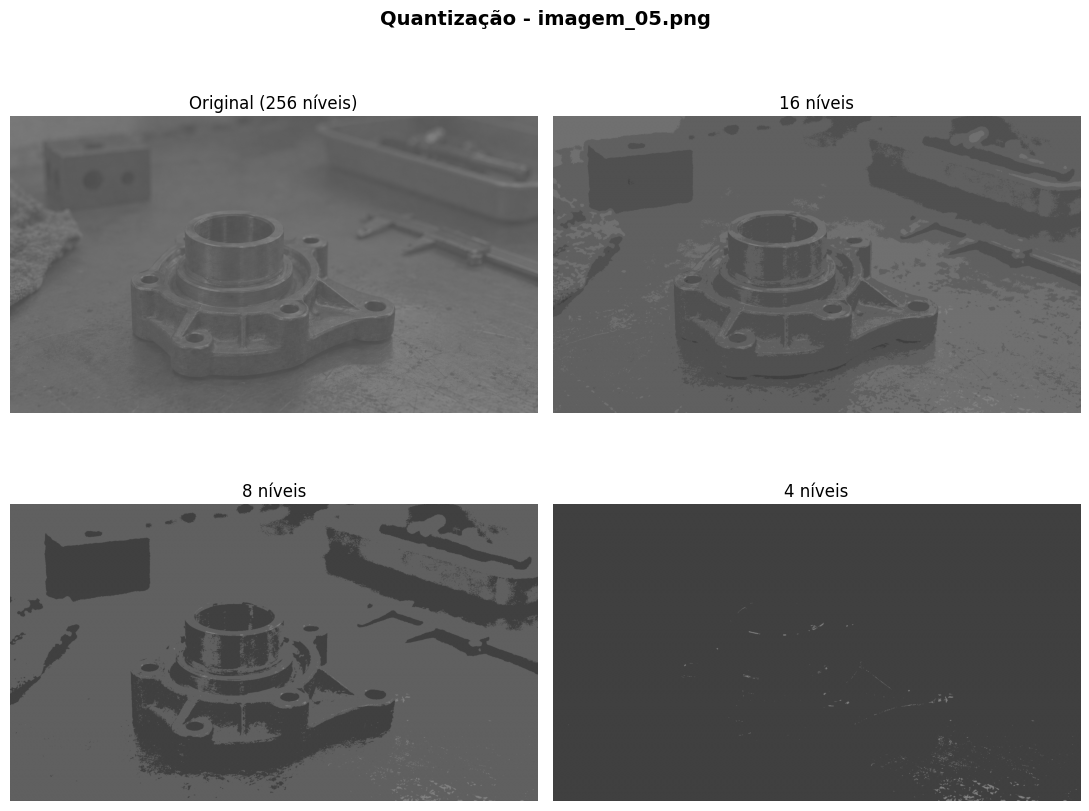

In [43]:
q16 = quantizar(img5, 16)
q8 = quantizar(img5, 8)
q4 = quantizar(img5, 4)

fig, axs = plt.subplots(2, 2, figsize=(11, 9))
fig.suptitle("Quantização - imagem_05.png", fontsize=14, fontweight="bold")

axs[0, 0].imshow(img5, cmap="gray", vmin=0, vmax=255)
axs[0, 0].set_title("Original (256 níveis)")
axs[0, 0].axis("off")

axs[0, 1].imshow(q16, cmap="gray", vmin=0, vmax=255)
axs[0, 1].set_title("16 níveis")
axs[0, 1].axis("off")

axs[1, 0].imshow(q8, cmap="gray", vmin=0, vmax=255)
axs[1, 0].set_title("8 níveis")
axs[1, 0].axis("off")

axs[1, 1].imshow(q4, cmap="gray", vmin=0, vmax=255)
axs[1, 1].set_title("4 níveis")
axs[1, 1].axis("off")

plt.tight_layout()
plt.show()


**Comentário:**
Como a imagem já possui baixíssimo contraste original, a quantização é ainda mais agressiva: em 16 níveis a perda já é perceptível, em 8 níveis a imagem perde quase toda a informação de textura, e em 4 níveis a imagem colapsa quase inteiramente em um único tom, perdendo praticamente toda a forma da peça — evidenciando que imagens de baixo contraste são muito mais sensíveis à redução de níveis de cinza.

## 9. Conclusão

Cada uma das cinco imagens apresentava um problema distinto de visualização, tratado com uma técnica diferente:

| Imagem | Problema identificado | Técnica aplicada |
|---|---|---|
| imagem_01.png (sementes) | Histograma bimodal / necessidade de segmentação | Limiarização |
| imagem_02.png (corredor) | Subexposição severa | Correção Gamma |
| imagem_03.png (turbina) | Polaridade tonal invertida | Negativo digital |
| imagem_04.png (rua) | Baixo contraste / neblina | Equalização de histograma |
| imagem_05.png (peça) | Faixa dinâmica estreita | Expansão de contraste |

Além disso, a quantização da imagem_05.png mostrou que a redução do número de níveis de cinza é aceitável até 16 níveis, mas se torna visualmente prejudicial a partir de 8 e principalmente 4 níveis.